In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kolinco/rna-squ/TCGA-PANCAN-HiSeq-801x20531/TCGA-PANCAN-HiSeq-801x20531/data.csv
/kaggle/input/datasets/kolinco/rna-squ/TCGA-PANCAN-HiSeq-801x20531/TCGA-PANCAN-HiSeq-801x20531/labels.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
data=pd.read_csv("/kaggle/input/datasets/kolinco/rna-squ/TCGA-PANCAN-HiSeq-801x20531/TCGA-PANCAN-HiSeq-801x20531/data.csv")

In [4]:
data.head(5)

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [8]:
labels=pd.read_csv("/kaggle/input/datasets/kolinco/rna-squ/TCGA-PANCAN-HiSeq-801x20531/TCGA-PANCAN-HiSeq-801x20531/labels.csv")

In [9]:
labels.head(10)

,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA
5,sample_5,PRAD
6,sample_6,KIRC
7,sample_7,PRAD
8,sample_8,BRCA
9,sample_9,PRAD


In [10]:
print("Data shape:", data.shape)        
print("Labels shape:", labels.shape)   
print("\nCancer type counts:")
print(labels['Class'].value_counts())
print("\nFirst few gene values:")
print(data.iloc[:3, :5])

Data shape: (801, 20532)
Labels shape: (801, 2)

Cancer type counts:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First few gene values:
  Unnamed: 0  gene_0    gene_1    gene_2    gene_3
0   sample_0     0.0  2.017209  3.265527  5.478487
1   sample_1     0.0  0.592732  1.588421  7.586157
2   sample_2     0.0  3.511759  4.327199  6.881787


In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 2a: Keep only numeric columns
data = data.select_dtypes(include=[np.number])

# Remove zero variance genes
before = data.shape[1]
data = data.loc[:, data.std() > 0]
after = data.shape[1]

print(f"Genes before filtering: {before}")
print(f"Genes after filtering: {after}")

# Step 2b: Log transform
data_log = np.log1p(data)

# Step 2c: Standardize
scaler = StandardScaler()
X = scaler.fit_transform(data_log)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels['Class'].values)
class_names = le.classes_

print("\nClass mapping:", dict(zip(range(len(class_names)), class_names)))
print("X shape:", X.shape)
print("y unique values:", np.unique(y))

Genes before filtering: 20531
Genes after filtering: 20264

Class mapping: {0: 'BRCA', 1: 'COAD', 2: 'KIRC', 3: 'LUAD', 4: 'PRAD'}
X shape: (801, 20264)
y unique values: [0 1 2 3 4]


Variance explained by PC1: 10.4%
Variance explained by PC2: 8.6%
Total variance explained:  19.0%


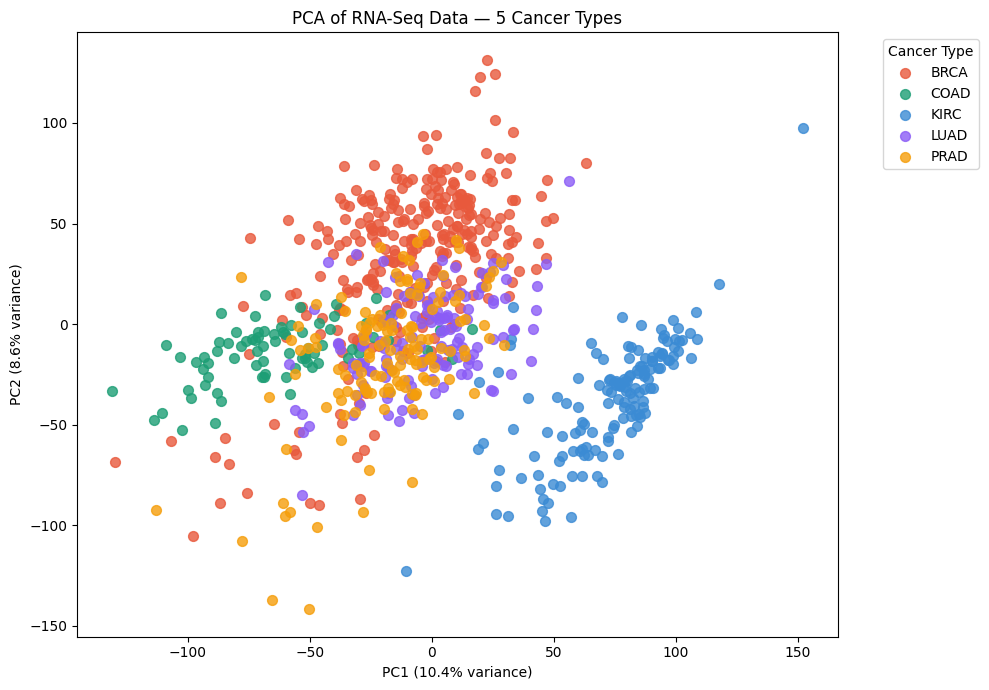

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Color map for 5 cancer types
palette = {
    'BRCA': '#E8593C',  # coral
    'KIRC': '#3B8BD4',  # blue
    'COAD': '#1D9E75',  # teal
    'LUAD': '#8B5CF6',  # purple
    'PRAD': '#F59E0B',  # amber
}

plt.figure(figsize=(10, 7))
for i, cancer_type in enumerate(class_names):
    mask = y == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=cancer_type,
        alpha=0.8,
        s=50,
        color=palette.get(cancer_type)
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of RNA-Seq Data — 5 Cancer Types')
plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Training samples: 640
Test samples:     161

Test Accuracy: 98.76%

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



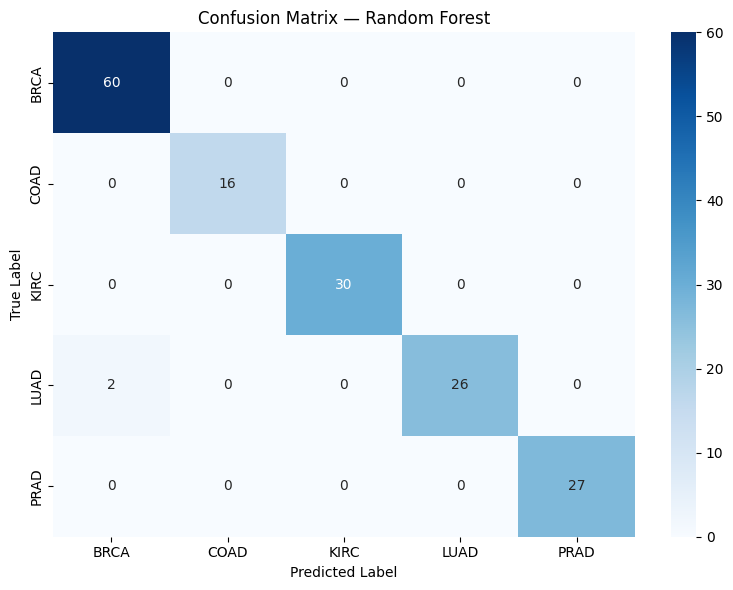

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# Train model
rf = RandomForestClassifier(
    n_estimators=200,       # 200 trees — good balance of accuracy vs speed
    max_features='sqrt',    # Standard for classification: sqrt(n_features)
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# --- Results ---
acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*40}")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"{'='*40}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Top 20 most important genes:
gene_2747     0.007462
gene_220      0.006921
gene_18746    0.006778
gene_18381    0.005895
gene_13210    0.005781
gene_15898    0.005633
gene_3439     0.005550
gene_203      0.005204
gene_9176     0.005204
gene_15895    0.005121
gene_7116     0.004741
gene_4288     0.004700
gene_5657     0.004640
gene_15987    0.004602
gene_18753    0.004501
gene_6748     0.004490
gene_4178     0.004474
gene_15633    0.004456
gene_7896     0.004387
gene_5577     0.004373


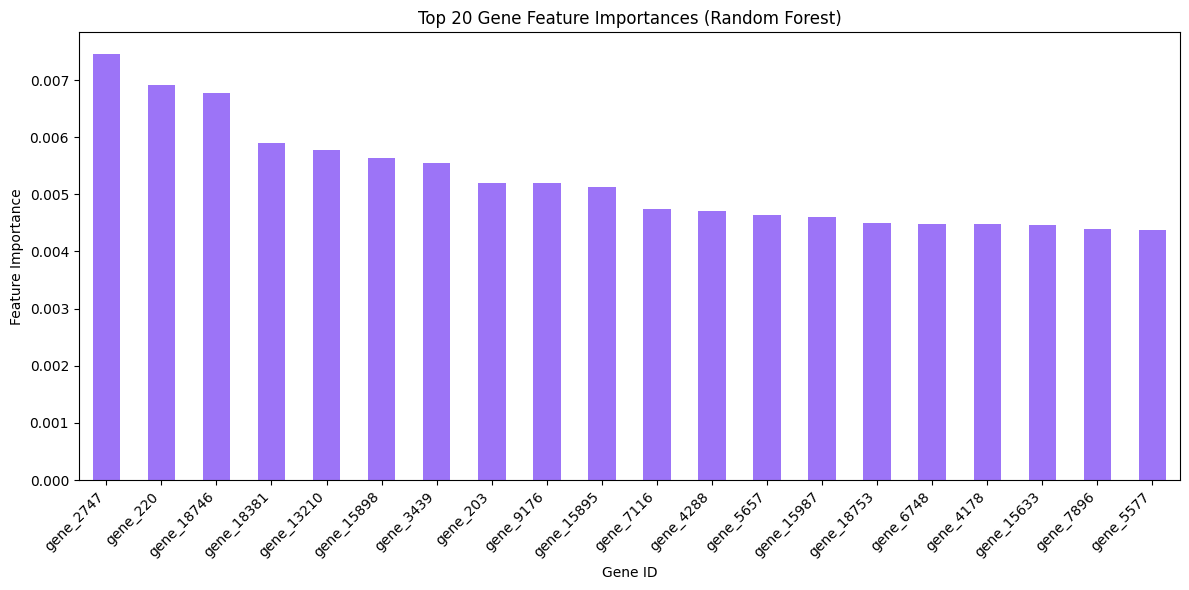

In [15]:
# Get feature importances mapped to gene names
gene_names = data.columns.tolist()   # gene_0, gene_1, ... gene_N
importances = rf.feature_importances_

# Sort descending
importance_series = pd.Series(importances, index=gene_names)
top_genes = importance_series.sort_values(ascending=False).head(20)

print("Top 20 most important genes:")
print(top_genes.to_string())

# Bar chart of top 20
plt.figure(figsize=(12, 6))
top_genes.plot(kind='bar', color='#8B5CF6', alpha=0.85)
plt.title('Top 20 Gene Feature Importances (Random Forest)')
plt.xlabel('Gene ID')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Method: use the original column names from the raw data
# The UCI dataset's gene columns ARE the actual gene names
# (e.g., the column header might already be 'TP53', 'BRCA1', etc.)

# Check your actual column names:
print("First 10 column names:", data.columns[:10].tolist())

# If they look like gene symbols (e.g. 'KRT19', 'GATA3'):
top_10_real = importance_series.sort_values(ascending=False).head(10)
print("\nTop 10 gene names to look up:")
for gene, imp in top_10_real.items():
    print(f"  {gene:20s}  importance={imp:.5f}")

First 10 column names: ['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_6', 'gene_7', 'gene_8', 'gene_9', 'gene_10']

Top 10 gene names to look up:
  gene_2747             importance=0.00746
  gene_220              importance=0.00692
  gene_18746            importance=0.00678
  gene_18381            importance=0.00590
  gene_13210            importance=0.00578
  gene_15898            importance=0.00563
  gene_3439             importance=0.00555
  gene_203              importance=0.00520
  gene_9176             importance=0.00520
  gene_15895            importance=0.00512


In [17]:
gene_id=pd.read_csv('/kaggle/input/datasets/kolinco/gene-id/genesID.csv')

In [22]:
gene_id.head(100)

,gene_id,gene_name
0,0,?|100130426
1,1,?|100133144
2,2,?|100134869
3,3,?|10357
4,4,?|10431
...,...,...
95,95,ABCC9|10060
96,96,ABCD1|215
97,97,ABCD2|225
98,98,ABCD3|5825


In [23]:
import pandas as pd

# Load the mapping file
gene_id = pd.read_csv('/kaggle/input/datasets/kolinco/gene-id/genesID.csv')

# Parse out clean symbol and entrez ID
gene_id['symbol'] = gene_id['gene_name'].apply(lambda x: x.split('|')[0])
gene_id['entrez_id'] = gene_id['gene_name'].apply(lambda x: x.split('|')[1])

# Convert gene_id number to match your column naming (gene_0, gene_1...)
gene_id['col_name'] = 'gene_' + gene_id['gene_id'].astype(str)

print(gene_id[['col_name', 'symbol', 'entrez_id']].head(10))

  col_name symbol  entrez_id
0   gene_0      ?  100130426
1   gene_1      ?  100133144
2   gene_2      ?  100134869
3   gene_3      ?      10357
4   gene_4      ?      10431
5   gene_5      ?     136542
6   gene_6      ?     155060
7   gene_7      ?      26823
8   gene_8      ?     280660
9   gene_9      ?     317712


In [24]:
# Your top genes from the model
top_genes_df = importance_series.sort_values(ascending=False).head(10).reset_index()
top_genes_df.columns = ['col_name', 'importance']

# Merge with gene mapping
top_genes_named = top_genes_df.merge(
    gene_id[['col_name', 'symbol', 'entrez_id']],
    on='col_name',
    how='left'
)

print(top_genes_named[['col_name', 'symbol', 'entrez_id', 'importance']].to_string(index=False))

  col_name  symbol entrez_id  importance
 gene_2747 C8orf85    441376    0.007462
  gene_220  ACSM2B    348158    0.006921
gene_18746   TRPS1      7227    0.006778
gene_18381 TMPRSS2      7113    0.005895
gene_13210   PDZD3     79849    0.005781
gene_15898   SFTPB      6439    0.005633
 gene_3439   CDH16      1014    0.005550
  gene_203    ACPP        55    0.005204
 gene_9176    KLK3       354    0.005204
gene_15895   SFTA3    253970    0.005121


In [25]:
# After your GeneCards lookup, fill this in manually:
bio_results = pd.DataFrame({
    'col_name':   top_genes_named['col_name'],
    'symbol':     top_genes_named['symbol'],
    'importance': top_genes_named['importance'],
    'cancer_link': [
        # Fill in after GeneCards — one entry per gene
        # e.g. 'Breast cancer (BRCA)', 'Prostate cancer (PRAD)', 'Unknown', etc.
        '?', '?', '?', '?', '?', '?', '?', '?', '?', '?'
    ]
})

print(bio_results.to_string(index=False))

  col_name  symbol  importance cancer_link
 gene_2747 C8orf85    0.007462           ?
  gene_220  ACSM2B    0.006921           ?
gene_18746   TRPS1    0.006778           ?
gene_18381 TMPRSS2    0.005895           ?
gene_13210   PDZD3    0.005781           ?
gene_15898   SFTPB    0.005633           ?
 gene_3439   CDH16    0.005550           ?
  gene_203    ACPP    0.005204           ?
 gene_9176    KLK3    0.005204           ?
gene_15895   SFTA3    0.005121           ?


In [26]:
bio_results = pd.DataFrame({
    'col_name':   top_genes_named['col_name'].tolist(),
    'symbol':     top_genes_named['symbol'].tolist(),
    'importance': top_genes_named['importance'].tolist(),
    'cancer_link': [
        'Unknown / candidate biomarker',       # C8orf85  gene_2747
        'Kidney cancer (KIRC)',                 # ACSM2B   gene_220
        'Breast cancer (BRCA)',                 # TRPS1    gene_18746
        'Prostate cancer (PRAD)',               # TMPRSS2  gene_18381
        'Multi-type / epithelial marker',       # PDZD3    gene_13210
        'Lung adenocarcinoma (LUAD)',           # SFTPB    gene_15898
        'Kidney cancer (KIRC)',                 # CDH16    gene_3439
        'Prostate cancer (PRAD)',               # ACPP     gene_203
        'Prostate cancer (PRAD)',               # KLK3     gene_9176
        'Lung adenocarcinoma (LUAD)',           # SFTA3    gene_15895
    ],
    'role': [
        'Poorly characterised open reading frame',
        'Acyl-CoA synthetase, lost in renal carcinoma',
        'Transcription repressor, luminal breast marker',
        'Androgen-regulated protease, TMPRSS2-ERG fusion driver',
        'PDZ-domain scaffold, epithelial polarity',
        'Surfactant protein B, alveolar epithelium marker',
        'Kidney-specific cadherin, renal tubular epithelium',
        'Prostatic Acid Phosphatase (PAP), historic PRAD marker',
        'Encodes PSA — the clinical prostate cancer blood test',
        'Surfactant-associated protein, lung-specific expression',
    ],
    'validation': [
        'Novel — no established link',
        'Good — tissue-specific expression',
        'Strong — established BRCA marker',
        'Strong — TMPRSS2-ERG is hallmark of PRAD',
        'Partial — tissue expression pattern',
        'Strong — LUAD originates from alveolar cells',
        'Strong — kidney-specific gene',
        'Strong — classic clinical PRAD biomarker',
        'Strong — PSA is the global PRAD diagnostic',
        'Strong — paired surfactant gene with SFTPB',
    ]
})

# Print full table
print(bio_results.to_string(index=False))

  col_name  symbol  importance                    cancer_link                                                    role                                   validation
 gene_2747 C8orf85    0.007462  Unknown / candidate biomarker                 Poorly characterised open reading frame                  Novel — no established link
  gene_220  ACSM2B    0.006921           Kidney cancer (KIRC)            Acyl-CoA synthetase, lost in renal carcinoma            Good — tissue-specific expression
gene_18746   TRPS1    0.006778           Breast cancer (BRCA)          Transcription repressor, luminal breast marker             Strong — established BRCA marker
gene_18381 TMPRSS2    0.005895         Prostate cancer (PRAD)  Androgen-regulated protease, TMPRSS2-ERG fusion driver     Strong — TMPRSS2-ERG is hallmark of PRAD
gene_13210   PDZD3    0.005781 Multi-type / epithelial marker                PDZ-domain scaffold, epithelial polarity          Partial — tissue expression pattern
gene_15898   SFTPB    

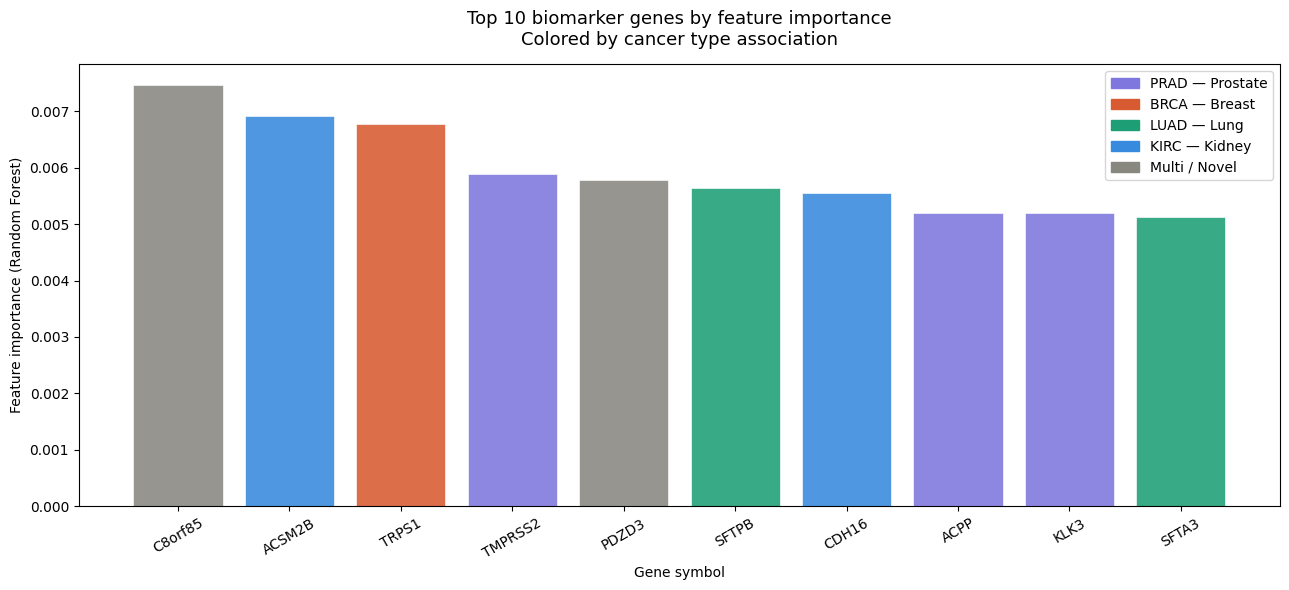

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_map = {
    'Prostate cancer (PRAD)':        '#7F77DD',
    'Breast cancer (BRCA)':          '#D85A30',
    'Lung adenocarcinoma (LUAD)':    '#1D9E75',
    'Kidney cancer (KIRC)':          '#378ADD',
    'Multi-type / epithelial marker':'#888780',
    'Unknown / candidate biomarker': '#888780',
}

colors = [color_map[c] for c in bio_results['cancer_link']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(bio_results['symbol'], bio_results['importance'],
              color=colors, alpha=0.88, edgecolor='white', linewidth=0.5)

ax.set_title('Top 10 biomarker genes by feature importance\nColored by cancer type association',
             fontsize=13, pad=14)
ax.set_xlabel('Gene symbol')
ax.set_ylabel('Feature importance (Random Forest)')
ax.tick_params(axis='x', rotation=30)

# Legend
legend_patches = [
    mpatches.Patch(color='#7F77DD', label='PRAD — Prostate'),
    mpatches.Patch(color='#D85A30', label='BRCA — Breast'),
    mpatches.Patch(color='#1D9E75', label='LUAD — Lung'),
    mpatches.Patch(color='#378ADD', label='KIRC — Kidney'),
    mpatches.Patch(color='#888780', label='Multi / Novel'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('biomarker_validation_chart.png', dpi=150, bbox_inches='tight')
plt.show()